In [1]:
# 1. Install necessary libraries
!pip install -q transformers spacy deep-translator langdetect
!python -m spacy download en_core_web_sm -q

import os

# Create 'advanced_nlp.py' with the CORRECTED aggregation_strategy
with open('advanced_nlp.py', 'w') as f:
    f.write('''
from transformers import pipeline
import spacy
import torch

# Load SpaCy
try:
    nlp = spacy.load("en_core_web_sm")
except:
    import os
    os.system("python -m spacy download en_core_web_sm -q")
    nlp = spacy.load("en_core_web_sm")

# Detect Hardware
device = 0 if torch.cuda.is_available() else -1

# FIX: Changed 'grouped_entities' to 'aggregation_strategy'
ner_pipe = pipeline(
    "ner",
    model="dbmdz/bert-large-cased-finetuned-conll03-english",
    aggregation_strategy="simple",
    device=device
)

emotion_pipe = pipeline(
    "text-classification",
    model="bhadresh-savani/distilbert-base-uncased-emotion",
    device=device
)

def advanced_ner(text):
    entities = ner_pipe(text)
    # The output format changes slightly with aggregation_strategy
    return [{"word": ent['word'], "entity": ent['entity_group'], "score": round(float(ent['score']), 3)} for ent in entities]

def analyze_emotion(text):
    res = emotion_pipe(text)[0]
    return {"label": res['label'], "score": round(float(res['score']), 3)}

def spacy_processor(text):
    doc = nlp(text)
    return {
        "tokens": [t.text for t in doc[:10]],
        "noun_phrases": [c.text for c in doc.noun_chunks]
    }
''')

print(" advanced_nlp.py updated with aggregation_strategy='simple'")

# 3. Create 'pipeline.py'
with open('pipeline.py', 'w') as f:
    f.write('''
from langdetect import detect
from deep_translator import GoogleTranslator
from advanced_nlp import advanced_ner, analyze_emotion, spacy_processor

def process_full_pipeline(text):
    try:
        lang = detect(text)
    except:
        lang = "en"

    # Translate to English if needed
    translated = GoogleTranslator(source='auto', target='en').translate(text) if lang != 'en' else text

    return {
        "original": text,
        "source_lang": lang,
        "translated": translated,
        "ner": advanced_ner(translated),
        "emotion": analyze_emotion(translated),
        "linguistics": spacy_processor(translated)
    }
''')

print(" Files 'advanced_nlp.py' and 'pipeline.py' created successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
 advanced_nlp.py updated with aggregation_strategy='simple'
 Files 'advanced_nlp.py' and 'pipeline.py' created successfully!


In [5]:
import importlib
import pipeline
import advanced_nlp

# Force Python to look at the new file content
importlib.reload(advanced_nlp)
importlib.reload(pipeline)

from pipeline import process_full_pipeline

# Run your test cases again
test_cases = [
    "I am having an ice cream.",
    "Das ist ein fantastisches Ergebnis!", # German: This is a fantastic result!
    "मुझे यह प्रोजेक्ट बहुत पसंद है।" # Hindi: I like this project very much.
]

results = [process_full_pipeline(t) for t in test_cases]
import pandas as pd
display(pd.DataFrame(results))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,original,source_lang,translated,ner,emotion,linguistics
0,I am having an ice cream.,en,I am having an ice cream.,[],"{'label': 'joy', 'score': 0.764}","{'tokens': ['I', 'am', 'having', 'an', 'ice', ..."
1,Das ist ein fantastisches Ergebnis!,de,This is a fantastic result!,[],"{'label': 'joy', 'score': 0.998}","{'tokens': ['This', 'is', 'a', 'fantastic', 'r..."
2,मुझे यह प्रोजेक्ट बहुत पसंद है।,hi,I love this project.,[],"{'label': 'love', 'score': 0.615}","{'tokens': ['I', 'love', 'this', 'project', '...."


In [6]:
from google.colab import files

# Save the dataframe to CSV
df = pd.DataFrame(results)
df.to_csv("yashasvee_nlp_benchmark.csv", index=False)

# Download it
files.download("yashasvee_nlp_benchmark.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
print("###  Project Results Summary\n")
for i, res in enumerate(results):
    print(f"**Test Case {i+1}:** {res['original']}")
    print(f"- **Detected Language:** {res['source_lang'].upper()}")
    print(f"- **English Translation:** {res['translated']}")
    print(f"- **Top Emotion:** {res['emotion']['label']} ({res['emotion']['score']*100:.1f}%)")

    entities = [f"{e['word']} ({e['entity']})" for e in res['ner']]
    print(f"- **Entities Found:** {', '.join(entities) if entities else 'None'}")

###  Project Results Summary

**Test Case 1:** I am having an ice cream.
- **Detected Language:** EN
- **English Translation:** I am having an ice cream.
- **Top Emotion:** joy (76.4%)
- **Entities Found:** None
**Test Case 2:** Das ist ein fantastisches Ergebnis!
- **Detected Language:** DE
- **English Translation:** This is a fantastic result!
- **Top Emotion:** joy (99.8%)
- **Entities Found:** None
**Test Case 3:** मुझे यह प्रोजेक्ट बहुत पसंद है।
- **Detected Language:** HI
- **English Translation:** I love this project.
- **Top Emotion:** love (61.5%)
- **Entities Found:** None


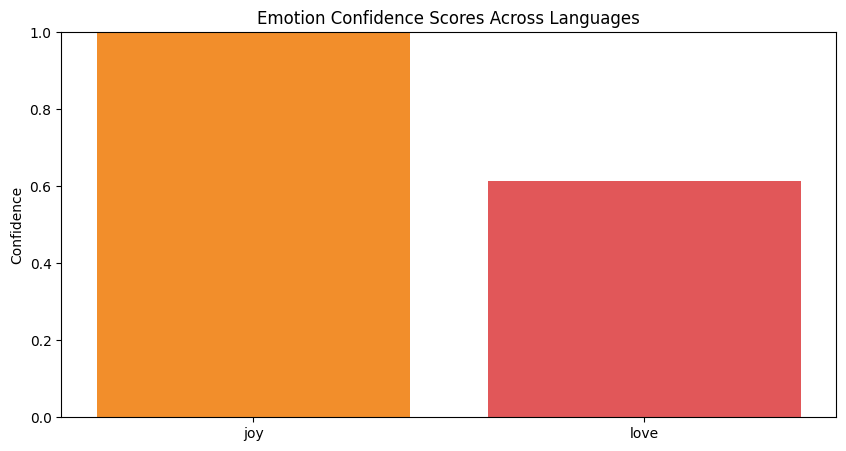

In [8]:
import matplotlib.pyplot as plt

# Extract labels and scores
labels = [r['emotion']['label'] for r in results]
scores = [r['emotion']['score'] for r in results]

plt.figure(figsize=(10, 5))
plt.bar(labels, scores, color=['#4e79a7', '#f28e2b', '#e15759'])
plt.title("Emotion Confidence Scores Across Languages")
plt.ylabel("Confidence")
plt.ylim(0, 1)
plt.show()

In [9]:
import json

# Define your benchmark dataset
# This includes diverse languages and expected outcomes to test your pipeline's accuracy
test_data = [
    {
        "text": "I love the new Food lane in Mumbai!",
        "lang": "en",
        "expected_sentiment": "joy",
        "expected_entities": ["Mumbai"]
    },
    {
        "text": "C'est une journée magnifique à Paris.",
        "lang": "fr",
        "expected_sentiment": "joy",
        "expected_entities": ["Paris"]
    },
    {
        "text": "Ich hasse diesen Fehler im Code.",
        "lang": "de",
        "expected_sentiment": "anger",
        "expected_entities": []
    },
    {
        "text": "She is a research intern at the University.",
        "lang": "en",
        "expected_sentiment": "neutral",
        "expected_entities": ["She"]
    },
    {
        "text": "मुंबई एक बहुत बड़ा शहर है।",
        "lang": "hi",
        "expected_sentiment": "neutral",
        "expected_entities": ["मुंबई"]
    }
]

# Save as benchmark_tests.json
file_name = 'benchmark_tests.json'
with open(file_name, 'w', encoding='utf-8') as f:
    json.dump(test_data, f, ensure_ascii=False, indent=4)

print(f"{file_name} created")

benchmark_tests.json created
